In [ ]:
# ============================================================
# M4 FUSION MODEL: Raw ECG + Spectrogram + 132 Features
# ============================================================

!pip install wfdb -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 152.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['MailTemplates  Receipt958275109112023190132.pdf', 'Colab Notebooks', 'Ashritha_Kotagiri_Resume  (1).pdf', 'Ashritha_Kotagiri_Resume .pdf', '20VE1A6785 2 (1).pdf', '20VE1A6785 2.pdf', 'Academic Transcript (1) (1).pdf', 'Academic Transcript (1).pdf']


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
print(os.path.exists("/content/drive/MyDrive/Colab Notebooks/ptbxl_one_ecg_per_patient_6classes.csv"))
print(os.path.exists("/content/drive/MyDrive/Colab Notebooks/ecg_132_features_per_patient.csv"))

True
True


In [ ]:
BASE_PATH = "/content/drive/MyDrive"
META_PATH = BASE_PATH + "/ptbxl_one_ecg_per_patient_6classes.csv"
FEATURE_PATH = BASE_PATH + "/ecg_132_features_per_patient.csv"
X_RAW_PATH = BASE_PATH + "/PTBXL/Copy of X_ptbxl_500hz.npy"

In [ ]:
meta = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ptbxl_one_ecg_per_patient_6classes.csv")
features_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ecg_132_features_per_patient.csv")

print(meta.shape)
print(features_df.shape)

(16004, 15)
(21799, 134)


In [ ]:
import os, numpy as np, pandas as pd, ast, torch

BASE = "/content/drive/MyDrive/Colab Notebooks"
X_NPY = os.path.join(BASE, "X_ptbxl_500hz.npy")
META  = os.path.join(BASE, "ptbxl_database.csv")
SCP   = os.path.join(BASE, "scp_statements.csv")

print("X:", os.path.exists(X_NPY))
print("META:", os.path.exists(META))
print("SCP:", os.path.exists(SCP))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X: True
META: True
SCP: True
Device: cuda


In [ ]:
!cp "{X_NPY}" /content/X_ptbxl_500hz.npy

X = np.load("/content/X_ptbxl_500hz.npy", mmap_mode="r")
print("X shape:", X.shape)  # expect (N,12,5000) or (N,5000,12)

X shape: (21799, 12, 5000)


In [ ]:
import pandas as pd
import numpy as np

ptbxl_db = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ptbxl_database.csv")

print("ptbxl_db:", ptbxl_db.shape)
print("X:", X.shape)
print("meta:", meta.shape)

ptbxl_db: (21799, 28)
X: (21799, 12, 5000)
meta: (16004, 15)


In [ ]:
# make ecg_id -> row index mapping
ptbxl_db = ptbxl_db.reset_index()
ecg_id_to_row = dict(zip(ptbxl_db["ecg_id"], ptbxl_db["index"]))

# keep only meta rows that exist in X/database
meta = meta[meta["ecg_id"].isin(ecg_id_to_row.keys())].reset_index(drop=True)

raw_indices = meta["ecg_id"].map(ecg_id_to_row).values

X_raw = np.asarray(X[raw_indices]).astype(np.float32)

print("X_raw:", X_raw.shape)
print("meta:", meta.shape)

X_raw: (16004, 12, 5000)
meta: (16004, 15)


In [ ]:
classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
label_cols = [f"y_{c}" for c in classes]

Y = meta[label_cols].values.astype(np.float32)

feature_cols = [c for c in features_df.columns if c not in ["ecg_id", "patient_id"]]

# if features not merged yet
if feature_cols[0] not in meta.columns:
    meta = meta.merge(
        features_df[["ecg_id"] + feature_cols],
        on="ecg_id",
        how="left"
    )

meta[feature_cols] = meta[feature_cols].fillna(0)

X_features = meta[feature_cols].values.astype(np.float32)

from sklearn.preprocessing import StandardScaler
X_features = StandardScaler().fit_transform(X_features).astype(np.float32)

print("X_raw:", X_raw.shape)
print("X_features:", X_features.shape)
print("Y:", Y.shape)

X_raw: (16004, 12, 5000)
X_features: (16004, 132)
Y: (16004, 6)


In [ ]:
from scipy.signal import spectrogram
import numpy as np

def make_spec(ecg):
    specs = []
    for lead in range(12):
        f, t, Sxx = spectrogram(
            ecg[lead],
            fs=500,
            nperseg=128,
            noverlap=64
        )
        specs.append(np.log1p(Sxx))
    return np.stack(specs).astype(np.float32)

X_specs = []

for i in range(len(X_raw)):
    if i % 1000 == 0:
        print("STFT:", i)
    X_specs.append(make_spec(X_raw[i]))

X_specs = np.stack(X_specs)

print("X_specs:", X_specs.shape)

STFT: 0
STFT: 1000
STFT: 2000
STFT: 3000
STFT: 4000
STFT: 5000
STFT: 6000
STFT: 7000
STFT: 8000
STFT: 9000
STFT: 10000
STFT: 11000
STFT: 12000
STFT: 13000
STFT: 14000
STFT: 15000
STFT: 16000
X_specs: (16004, 12, 65, 77)


In [ ]:
#Now train M4
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np

idx = np.arange(len(Y))

train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

class FusionDataset(Dataset):
    def __init__(self, X_raw, X_specs, X_features, Y, indices):
        self.X_raw = X_raw
        self.X_specs = X_specs
        self.X_features = X_features
        self.Y = Y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        return (
            torch.tensor(self.X_raw[i], dtype=torch.float32),
            torch.tensor(self.X_specs[i], dtype=torch.float32),
            torch.tensor(self.X_features[i], dtype=torch.float32),
            torch.tensor(self.Y[i], dtype=torch.float32)
        )

train_loader = DataLoader(FusionDataset(X_raw, X_specs, X_features, Y, train_idx), batch_size=32, shuffle=True)
val_loader   = DataLoader(FusionDataset(X_raw, X_specs, X_features, Y, val_idx), batch_size=32, shuffle=False)
test_loader  = DataLoader(FusionDataset(X_raw, X_specs, X_features, Y, test_idx), batch_size=32, shuffle=False)

In [ ]:
class RawBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(12, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, 128)

    def forward(self, x):
        return self.fc(self.net(x).squeeze(-1))


class SpecBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(12, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(128, 128)

    def forward(self, x):
        x = self.net(x)
        return self.fc(x.view(x.size(0), -1))


class FeatureBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(132, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class FusionM4(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.raw_branch = RawBranch()
        self.spec_branch = SpecBranch()
        self.feature_branch = FeatureBranch()

        self.classifier = nn.Sequential(
            nn.Linear(128 + 128 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, raw, spec, feat):
        r = self.raw_branch(raw)
        s = self.spec_branch(spec)
        f = self.feature_branch(feat)
        fused = torch.cat([r, s, f], dim=1)
        return self.classifier(fused)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FusionM4(num_classes=6).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float("inf")
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for raw, spec, feat, y in train_loader:
        raw = raw.to(device)
        spec = spec.to(device)
        feat = feat.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(raw, spec, feat)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * raw.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for raw, spec, feat, y in val_loader:
            raw = raw.to(device)
            spec = spec.to(device)
            feat = feat.to(device)
            y = y.to(device)

            logits = model(raw, spec, feat)
            loss = criterion(logits, y)

            val_loss += loss.item() * raw.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_m4_fusion.pth")
        print("Saved best M4")

Epoch 1/30 | Train Loss: 0.3117 | Val Loss: 0.3188
Saved best M4
Epoch 2/30 | Train Loss: 0.2545 | Val Loss: 0.2340
Saved best M4
Epoch 3/30 | Train Loss: 0.2374 | Val Loss: 0.3088
Epoch 4/30 | Train Loss: 0.2246 | Val Loss: 0.2363
Epoch 5/30 | Train Loss: 0.2144 | Val Loss: 0.2090
Saved best M4
Epoch 6/30 | Train Loss: 0.2017 | Val Loss: 0.1931
Saved best M4
Epoch 7/30 | Train Loss: 0.1967 | Val Loss: 0.2180
Epoch 8/30 | Train Loss: 0.1893 | Val Loss: 0.3260
Epoch 9/30 | Train Loss: 0.1861 | Val Loss: 0.4662
Epoch 10/30 | Train Loss: 0.1838 | Val Loss: 0.2087
Epoch 11/30 | Train Loss: 0.1830 | Val Loss: 0.3554
Epoch 12/30 | Train Loss: 0.1765 | Val Loss: 0.4153
Epoch 13/30 | Train Loss: 0.1743 | Val Loss: 0.2464
Epoch 14/30 | Train Loss: 0.1725 | Val Loss: 0.2167
Epoch 15/30 | Train Loss: 0.1744 | Val Loss: 0.6127
Epoch 16/30 | Train Loss: 0.1679 | Val Loss: 0.2411
Epoch 17/30 | Train Loss: 0.1655 | Val Loss: 0.3385
Epoch 18/30 | Train Loss: 0.1643 | Val Loss: 0.2292
Epoch 19/30 | Tra

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import torch

model.load_state_dict(torch.load("best_m4_fusion.pth"))
model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for raw, spec, feat, y in test_loader:
        raw = raw.to(device)
        spec = spec.to(device)
        feat = feat.to(device)

        logits = model(raw, spec, feat)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_true.append(y.numpy())

y_prob = np.vstack(all_probs)
y_true = np.vstack(all_true)

y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
print("M4 Fusion Per-Class Results:\n")

for i, c in enumerate(classes):
    print(c)
    print(" Accuracy :", accuracy_score(y_true[:, i], y_pred[:, i]))
    print(" Precision:", precision_score(y_true[:, i], y_pred[:, i], zero_division=0))
    print(" Recall   :", recall_score(y_true[:, i], y_pred[:, i], zero_division=0))
    print(" F1-score :", f1_score(y_true[:, i], y_pred[:, i], zero_division=0))
    print(" AUROC    :", roc_auc_score(y_true[:, i], y_prob[:, i]))
    print()

print("Overall M4 Results")
print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))
print("Macro AUROC    :", roc_auc_score(y_true, y_prob, average="macro"))

M4 Fusion Per-Class Results:

NORM
 Accuracy : 0.8742190753852561
 Precision: 0.8743455497382199
 Recall   : 0.8971603990790483
 F1-score : 0.8856060606060606
 AUROC    : 0.9491680261467511

IMI
 Accuracy : 0.8929612661391088
 Precision: 0.755
 Recall   : 0.4206128133704735
 F1-score : 0.5402504472271914
 AUROC    : 0.9211543655654651

ASMI
 Accuracy : 0.9421074552269888
 Precision: 0.7922077922077922
 Recall   : 0.7648902821316614
 F1-score : 0.7783094098883573
 AUROC    : 0.9727971356213431

LVH
 Accuracy : 0.931695127030404
 Precision: 0.8851351351351351
 Recall   : 0.4712230215827338
 F1-score : 0.6150234741784038
 AUROC    : 0.9544488761322547

NDT
 Accuracy : 0.9208663057059558
 Precision: 0.6666666666666666
 Recall   : 0.48
 F1-score : 0.5581395348837209
 AUROC    : 0.930229660622966

LAFB
 Accuracy : 0.9591836734693877
 Precision: 0.7272727272727273
 Recall   : 0.7431693989071039
 F1-score : 0.7351351351351352
 AUROC    : 0.9779720813808532

Overall M4 Results
Macro Precision: 

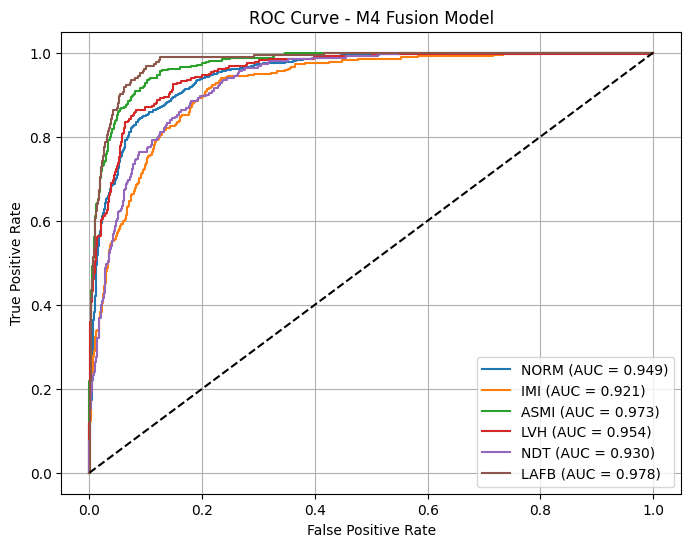

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{c} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')  # diagonal

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - M4 Fusion Model")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rows = []

for i, c in enumerate(classes):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

    rows.append({
        "Class": c,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4)
    })

df_metrics = pd.DataFrame(rows)
print(df_metrics)

  Class  Accuracy  Precision  Recall  F1-score
0  NORM    0.8742     0.8743  0.8972    0.8856
1   IMI    0.8930     0.7550  0.4206    0.5403
2  ASMI    0.9421     0.7922  0.7649    0.7783
3   LVH    0.9317     0.8851  0.4712    0.6150
4   NDT    0.9209     0.6667  0.4800    0.5581
5  LAFB    0.9592     0.7273  0.7432    0.7351


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

per_class_acc = []

for i in range(len(classes)):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    per_class_acc.append(acc)

macro_accuracy = np.mean(per_class_acc)

print("Macro Accuracy:", round(macro_accuracy, 4))

Macro Accuracy: 0.9202


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# class weights for imbalance
pos_counts = Y[train_idx].sum(axis=0)
neg_counts = len(train_idx) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

# new model
model = FusionM4(num_classes=6).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

best_val_loss = float("inf")
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for raw, spec, feat, y in train_loader:
        raw = raw.to(device)
        spec = spec.to(device)
        feat = feat.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(raw, spec, feat)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * raw.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for raw, spec, feat, y in val_loader:
            raw = raw.to(device)
            spec = spec.to(device)
            feat = feat.to(device)
            y = y.to(device)

            logits = model(raw, spec, feat)
            loss = criterion(logits, y)

            val_loss += loss.item() * raw.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_m4_fusion_weighted.pth")
        print("Saved best weighted M4")

Device: cuda
pos_weight: tensor([0.8358, 6.1946, 7.2916, 7.9473, 8.6155, 9.8337], device='cuda:0')
Epoch 1/30 | Train Loss: 0.9788 | Val Loss: 0.7562
Saved best weighted M4
Epoch 2/30 | Train Loss: 0.7448 | Val Loss: 0.7454
Saved best weighted M4
Epoch 3/30 | Train Loss: 0.6696 | Val Loss: 0.6217
Saved best weighted M4
Epoch 4/30 | Train Loss: 0.6368 | Val Loss: 0.6583
Epoch 5/30 | Train Loss: 0.6123 | Val Loss: 0.5999
Saved best weighted M4
Epoch 6/30 | Train Loss: 0.5795 | Val Loss: 0.5499
Saved best weighted M4
Epoch 7/30 | Train Loss: 0.5589 | Val Loss: 0.5391
Saved best weighted M4
Epoch 8/30 | Train Loss: 0.5331 | Val Loss: 0.7351
Epoch 9/30 | Train Loss: 0.5129 | Val Loss: 0.8070
Epoch 10/30 | Train Loss: 0.5066 | Val Loss: 0.5243
Saved best weighted M4
Epoch 11/30 | Train Loss: 0.4905 | Val Loss: 0.4810
Saved best weighted M4
Epoch 12/30 | Train Loss: 0.4819 | Val Loss: 0.4832
Epoch 13/30 | Train Loss: 0.4772 | Val Loss: 1.0574
Epoch 14/30 | Train Loss: 0.4672 | Val Loss: 1.479

In [ ]:
model.load_state_dict(torch.load("best_m4_fusion_weighted.pth"))
model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for raw, spec, feat, y in test_loader:
        raw = raw.to(device)
        spec = spec.to(device)
        feat = feat.to(device)

        logits = model(raw, spec, feat)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_true.append(y.numpy())

y_prob = np.vstack(all_probs)
y_true = np.vstack(all_true)

y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
print("Weighted M4 Per-Class Results:\n")

for i, c in enumerate(classes):
    print(c)
    print(" Accuracy :", accuracy_score(y_true[:, i], y_pred[:, i]))
    print(" Precision:", precision_score(y_true[:, i], y_pred[:, i], zero_division=0))
    print(" Recall   :", recall_score(y_true[:, i], y_pred[:, i], zero_division=0))
    print(" F1-score :", f1_score(y_true[:, i], y_pred[:, i], zero_division=0))
    print(" AUROC    :", roc_auc_score(y_true[:, i], y_prob[:, i]))
    print()

print("Overall Weighted M4 Results")
print("Macro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))
print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred, average="micro", zero_division=0))
print("Macro AUROC    :", roc_auc_score(y_true, y_prob, average="macro"))

per_class_acc = [accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(len(classes))]
print("Macro Accuracy:", np.mean(per_class_acc))

Weighted M4 Per-Class Results:

NORM
 Accuracy : 0.8775510204081632
 Precision: 0.8813303099017384
 Recall   : 0.8948580199539524
 F1-score : 0.8880426504188881
 AUROC    : 0.947617729577394

IMI
 Accuracy : 0.8508954602249063
 Precision: 0.5008403361344538
 Recall   : 0.83008356545961
 F1-score : 0.6247379454926625
 AUROC    : 0.9265112307285173

ASMI
 Accuracy : 0.9137859225322782
 Precision: 0.6314553990610329
 Recall   : 0.8432601880877743
 F1-score : 0.7221476510067114
 AUROC    : 0.9599342325169614

LVH
 Accuracy : 0.8658892128279884
 Precision: 0.4601449275362319
 Recall   : 0.9136690647482014
 F1-score : 0.6120481927710844
 AUROC    : 0.9511245454884327

NDT
 Accuracy : 0.8413161182840483
 Precision: 0.3844797178130511
 Recall   : 0.872
 F1-score : 0.5336597307221542
 AUROC    : 0.9248870292887029

LAFB
 Accuracy : 0.9458558933777592
 Precision: 0.5929824561403508
 Recall   : 0.9234972677595629
 F1-score : 0.7222222222222222
 AUROC    : 0.9841707440858944

Overall Weighted M4 R

In [ ]:
best_thresholds = []

for i, c in enumerate(classes):
    best_f1 = 0
    best_t = 0.5

    for t in np.arange(0.1, 0.9, 0.01):
        pred = (y_prob[:, i] >= t).astype(int)
        f1 = f1_score(y_true[:, i], pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds.append(best_t)
    print(c, "best threshold:", round(best_t, 2), "best F1:", round(best_f1, 4))

y_pred_tuned = np.zeros_like(y_pred)

for i, t in enumerate(best_thresholds):
    y_pred_tuned[:, i] = (y_prob[:, i] >= t).astype(int)

print("\nTuned Weighted M4 Results")
print("Macro Precision:", precision_score(y_true, y_pred_tuned, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred_tuned, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred_tuned, average="macro", zero_division=0))
print("Micro Precision:", precision_score(y_true, y_pred_tuned, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred_tuned, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred_tuned, average="micro", zero_division=0))

per_class_acc_tuned = [accuracy_score(y_true[:, i], y_pred_tuned[:, i]) for i in range(len(classes))]
print("Tuned Macro Accuracy:", np.mean(per_class_acc_tuned))

NORM best threshold: 0.42 best F1: 0.8918
IMI best threshold: 0.79 best F1: 0.6609
ASMI best threshold: 0.61 best F1: 0.7336
LVH best threshold: 0.84 best F1: 0.693
NDT best threshold: 0.65 best F1: 0.5732
LAFB best threshold: 0.87 best F1: 0.8022

Tuned Weighted M4 Results
Macro Precision: 0.6927876931482326
Macro Recall   : 0.7734353683064525
Macro F1       : 0.7257605200337977
Micro Precision: 0.7423887587822015
Micro Recall   : 0.8242942050520059
Micro F1       : 0.7812004928709734
Tuned Macro Accuracy: 0.9137165070109677


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

best_thresholds = []

for i, c in enumerate(classes):
    best_f1 = 0
    best_t = 0.5

    for t in np.arange(0.1, 0.9, 0.01):
        pred = (y_prob[:, i] >= t).astype(int)
        f1 = f1_score(y_true[:, i], pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds.append(best_t)
    print(c, "best threshold:", round(best_t, 2), "best F1:", round(best_f1, 4))

NORM best threshold: 0.42 best F1: 0.8918
IMI best threshold: 0.79 best F1: 0.6609
ASMI best threshold: 0.61 best F1: 0.7336
LVH best threshold: 0.84 best F1: 0.693
NDT best threshold: 0.65 best F1: 0.5732
LAFB best threshold: 0.87 best F1: 0.8022


In [ ]:
y_pred_tuned = np.zeros_like(y_pred)

for i, t in enumerate(best_thresholds):
    y_pred_tuned[:, i] = (y_prob[:, i] >= t).astype(int)

print("Tuned Macro F1:", f1_score(y_true, y_pred_tuned, average="macro", zero_division=0))

Tuned Macro F1: 0.7257605200337977


In [ ]:
pos_counts = Y[train_idx].sum(axis=0)
neg_counts = len(train_idx) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 25

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Tuned Per-Class Metrics:\n")

for i, c in enumerate(classes):
    print(c)
    print(" Accuracy :", accuracy_score(y_true[:, i], y_pred_tuned[:, i]))
    print(" Precision:", precision_score(y_true[:, i], y_pred_tuned[:, i], zero_division=0))
    print(" Recall   :", recall_score(y_true[:, i], y_pred_tuned[:, i], zero_division=0))
    print(" F1-score :", f1_score(y_true[:, i], y_pred_tuned[:, i], zero_division=0))
    print()

Tuned Per-Class Metrics:

NORM
 Accuracy : 0.8788004997917535
 Precision: 0.8650793650793651
 Recall   : 0.9201841903300076
 F1-score : 0.8917813313499442

IMI
 Accuracy : 0.9025406080799667
 Precision: 0.6888217522658611
 Recall   : 0.6350974930362117
 F1-score : 0.6608695652173913

ASMI
 Accuracy : 0.9237817576009996
 Precision: 0.6847826086956522
 Recall   : 0.7899686520376176
 F1-score : 0.7336244541484717

LVH
 Accuracy : 0.9254477301124532
 Precision: 0.6622950819672131
 Recall   : 0.7266187050359713
 F1-score : 0.692967409948542

NDT
 Accuracy : 0.8821324448146606
 Precision: 0.4600484261501211
 Recall   : 0.76
 F1-score : 0.5731523378582202

LAFB
 Accuracy : 0.9695960016659725
 Precision: 0.7956989247311828
 Recall   : 0.8087431693989071
 F1-score : 0.8021680216802168



In [ ]:
print("Tuned Overall Results")

print("Macro Precision:", precision_score(y_true, y_pred_tuned, average="macro", zero_division=0))
print("Macro Recall   :", recall_score(y_true, y_pred_tuned, average="macro", zero_division=0))
print("Macro F1       :", f1_score(y_true, y_pred_tuned, average="macro", zero_division=0))

print("Micro Precision:", precision_score(y_true, y_pred_tuned, average="micro", zero_division=0))
print("Micro Recall   :", recall_score(y_true, y_pred_tuned, average="micro", zero_division=0))
print("Micro F1       :", f1_score(y_true, y_pred_tuned, average="micro", zero_division=0))

Tuned Overall Results
Macro Precision: 0.6927876931482326
Macro Recall   : 0.7734353683064525
Macro F1       : 0.7257605200337977
Micro Precision: 0.7423887587822015
Micro Recall   : 0.8242942050520059
Micro F1       : 0.7812004928709734


In [ ]:
import numpy as np

per_class_acc = []

for i in range(len(classes)):
    acc = accuracy_score(y_true[:, i], y_pred_tuned[:, i])
    per_class_acc.append(acc)

macro_accuracy = np.mean(per_class_acc)

print("Tuned Macro Accuracy:", round(macro_accuracy, 4))

Tuned Macro Accuracy: 0.9137


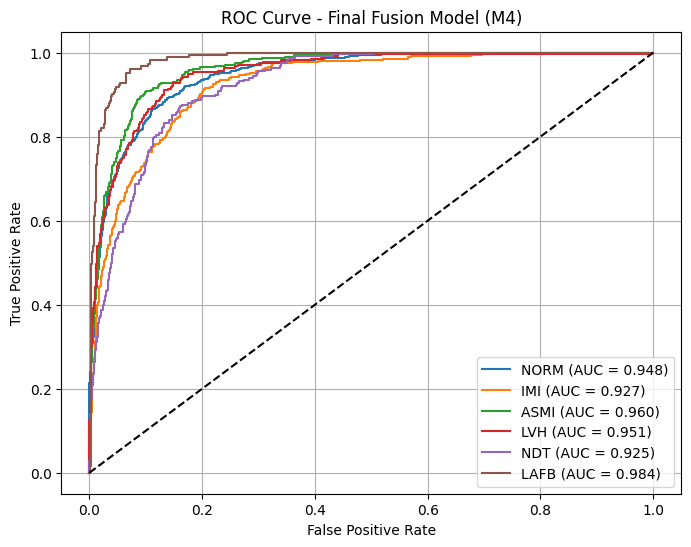

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{c} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Fusion Model (M4)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()